In [20]:
from PEPit import PEP
from PEPit.primitive_steps import inexact_gradient_step
from PEPit.functions import SmoothStronglyConvexQuadraticFunction, SmoothStronglyConvexFunction

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm_notebook


In [15]:
def nesterov_estimation_seq(L, mu, alpha, n, wrapper="cvxpy", solver=None, verbose=1):
    problem = PEP()
    func = problem.declare_function(SmoothStronglyConvexFunction, L=L, mu=mu)
    xs = func.stationary_point()
    fs = func(xs)
    x0 = problem.set_initial_point()

    problem.set_initial_condition((x0 - xs) ** 2 <= 100)

    h = 1 / L * ((1 - alpha) / (1 + alpha)) ** (3/2)
    L_hat = (1 + alpha) / ((1 - alpha) ** 3) * L
    rho = 1 + alpha
    nu = 1 - alpha
    s = rho ** 2 + alpha ** 2
    m = nu ** 2 - alpha ** 2
    q = mu / L_hat
    a = ((m - s) + np.sqrt((s - m) ** 2 + 4 * m * q)) / 2 / m

    u = x0
    x = x0

    for _ in range(n):
        y = (a * u + x) / (1 + a)
        _, g, _ = inexact_gradient_step(y, func, gamma=h, epsilon=alpha, notion='relative')
        u = (1 - a) * u + a * y - a / mu * g
        x = y - h * g

    problem.set_performance_metric(func(x) - fs)

    pepit_tau = problem.solve(wrapper=wrapper, solver=solver, verbose=False)

    if verbose != -1:
        print('\tPEPit guarantee:\t\t f(x_n)-f_* <= {:.6} ||x_0 - x_*||^2'.format(pepit_tau))

    return pepit_tau


In [46]:
mu = 1
L = 10
alpha = 0.6
pepit_tau = nesterov_estimation_seq(L=L, mu=mu, alpha=alpha, n=2, wrapper="cvxpy", solver=None, verbose=False)

print(pepit_tau)

(PEPit) Warning: the duality gap seems surprisingly large and negative.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 415.953 ||x_0 - x_*||^2
415.9533500890474


In [55]:
grid = range(5, 52, 10)

In [56]:
def calc_alpha(L, mu, alpha):
    taus = []
    for j in tqdm_notebook(grid):
        taus.append(nesterov_estimation_seq(L=L, mu=mu, alpha=alpha, n=j, wrapper="cvxpy", solver=None, verbose=False))
    return taus

In [34]:
def calc_tau(alpha, mu, L):
    return 0.5 - np.log(3 * alpha) / np.log(mu / L)

In [53]:
mu = 0.01
L = 100

In [33]:
mu = 0.01
L = 100
alpha = 0.1
taus_01 = calc_alpha(L=L, mu=mu, alpha=alpha)

  0%|          | 0/5 [00:00<?, ?it/s]

(PEPit) Warning: the duality gap seems surprisingly large.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 1365.15 ||x_0 - x_*||^2
(PEPit) Warning: the duality gap seems surprisingly large and negative.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 294.102 ||x_0 - x_*||^2
	PEPit guarantee:		 f(x_n)-f_* <= 164.827 ||x_0 - x_*||^2
	PEPit guarantee:		 f(x_n)-f_* <= 114.53 ||x_0 - x_*||^2
	PEPit guarantee:		 f(x_n)-f_* <= 87.7022 ||x_0 - x_*||^2


In [57]:
alpha = 0.33
taus_033 = calc_alpha(L=L, mu=mu, alpha=alpha)

  0%|          | 0/5 [00:00<?, ?it/s]

/home/victor/.pyenv/versions/3.9.7/lib/python3.9/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


(PEPit) Warning: the duality gap seems surprisingly large and negative.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 3414.19 ||x_0 - x_*||^2
(PEPit) Warning: the duality gap seems surprisingly large.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 618.436 ||x_0 - x_*||^2


/home/victor/.pyenv/versions/3.9.7/lib/python3.9/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


(PEPit) Warning: the duality gap seems surprisingly large and negative.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 394.219 ||x_0 - x_*||^2


/home/victor/.pyenv/versions/3.9.7/lib/python3.9/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


(PEPit) Warning: the duality gap seems surprisingly large and negative.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 292.134 ||x_0 - x_*||^2


/home/victor/.pyenv/versions/3.9.7/lib/python3.9/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


(PEPit) Warning: the duality gap seems surprisingly large and negative.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 227.909 ||x_0 - x_*||^2


In [58]:
alpha = 0.2
taus_02 = calc_alpha(L=L, mu=mu, alpha=alpha)

  0%|          | 0/5 [00:00<?, ?it/s]

/home/victor/.pyenv/versions/3.9.7/lib/python3.9/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


(PEPit) Warning: the duality gap seems surprisingly large.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 1078.92 ||x_0 - x_*||^2
(PEPit) Warning: the duality gap seems surprisingly large and negative.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 357.147 ||x_0 - x_*||^2
(PEPit) Warning: the duality gap seems surprisingly large and negative.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 222.316 ||x_0 - x_*||^2
	PEPit guarantee:		 f(x_n)-f_* <= 161.62 ||x_0 - x_*||^2
(PEPit) Warning: the duality gap seems surprisingly large.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 127.077 ||x_0 - x_*||^2


In [59]:
alpha = 0.05
taus_005 = calc_alpha(L=L, mu=mu, alpha=alpha)

  0%|          | 0/5 [00:00<?, ?it/s]

(PEPit) Warning: the duality gap seems surprisingly large.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 543.541 ||x_0 - x_*||^2
(PEPit) Warning: the duality gap seems surprisingly large and negative.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 193.777 ||x_0 - x_*||^2
	PEPit guarantee:		 f(x_n)-f_* <= 117.245 ||x_0 - x_*||^2
	PEPit guarantee:		 f(x_n)-f_* <= 83.6719 ||x_0 - x_*||^2
	PEPit guarantee:		 f(x_n)-f_* <= 64.8735 ||x_0 - x_*||^2


In [60]:
alpha = 0.01
taus_001 = calc_alpha(L=L, mu=mu, alpha=alpha)

  0%|          | 0/5 [00:00<?, ?it/s]

/home/victor/.pyenv/versions/3.9.7/lib/python3.9/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


(PEPit) Warning: the duality gap seems surprisingly large.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 448.525 ||x_0 - x_*||^2


/home/victor/.pyenv/versions/3.9.7/lib/python3.9/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


(PEPit) Warning: the duality gap seems surprisingly large and negative.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 125.707 ||x_0 - x_*||^2


...

(PEPit) Warning: the duality gap seems surprisingly large and negative.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 98.2581 ||x_0 - x_*||^2


/home/victor/.pyenv/versions/3.9.7/lib/python3.9/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


(PEPit) Warning: the duality gap seems surprisingly large and negative.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 130.011 ||x_0 - x_*||^2


/home/victor/.pyenv/versions/3.9.7/lib/python3.9/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


(PEPit) Warning: the duality gap seems surprisingly large and negative.
		The solver might not have converged properly.
		We recommend to use another solver for confirmation.
	PEPit guarantee:		 f(x_n)-f_* <= 100.977 ||x_0 - x_*||^2


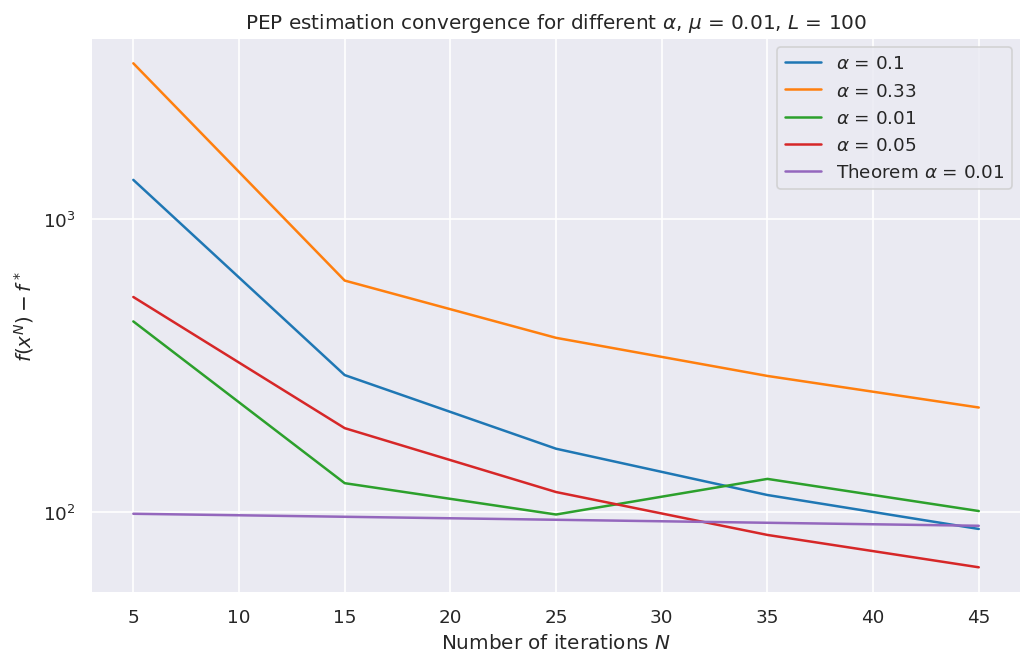

In [100]:
with sns.plotting_context('notebook'), sns.axes_style('darkgrid'):
    plt.figure(figsize=(10, 6), dpi=120)

    plt.semilogy(grid, taus_01, label=r"$\alpha$ = 0.1")
    plt.semilogy(grid, taus_033, label=r"$\alpha$ = 0.33")
    plt.semilogy(grid, taus_001, label=r"$\alpha$ = 0.01")
    plt.semilogy(grid, taus_005, label=r"$\alpha$ = 0.05")

    # q = ((mu / L) ** (0.5 + calc_tau(0.01 / 3, mu, L)))
    q = 1 - 1 / np.sqrt(2) * ((mu / L) ** (0.5 + calc_tau(0.01, mu, L)))
    #plt.semilogy(grid, L * np.exp(-q / 10 * np.array(grid)), label=r"Theorem $\alpha$ = 0.1")
    plt.semilogy(grid, L * q ** np.array(grid), label=r"Theorem $\alpha$ = 0.01")

    # q = 1 - 1 / 10 / np.sqrt(2) * ((mu / L) * (0.5 + calc_tau(0.33, mu, L)))
    # plt.semilogy(grid, L * q ** np.array(grid), label=r"Theorem $\alpha$ = 0.33")

    # q = 1 - 1 / 10 / np.sqrt(2) * ((mu / L) * (0.5 + calc_tau(0.01, mu, L)))
    # plt.semilogy(grid, L * q ** np.array(grid), label=r"Theorem $\alpha$ = 0.01")

    # q = 1 - 1 / 10 / np.sqrt(2) * ((mu / L) * (0.5 + calc_tau(0.05, mu, L)))
    # plt.semilogy(grid, L * q ** np.array(grid), label=r"Theorem $\alpha$ = 0.05")

    plt.xlabel(r"Number of iterations $N$")
    plt.ylabel(r"$f(x^N) - f^*$")
    plt.title(rf"PEP estimation convergence for different $\alpha$, $\mu$ = {mu}, $L$ = {L}")

    plt.legend()


In [87]:
q

6.192803136799156e-05

In [79]:
calc_tau(0.001, mu, L)

-0.13071968632008446

In [85]:
0.5 - np.log(3 * 0.01 / 2) / np.log(mu / L)

0.044022814763920226

In [82]:
np.log(mu / L)

-9.210340371976182

In [83]:
np.log(3 * 0.001)

-5.809142990314028

In [89]:
calc_tau(0.01 / 3, mu, L)

0.0